# K-Nearest Neighbours (KNN)
### The algorithm where the geometry is the model

KNN is one of the few ML algorithms where there is genuinely nothing to train. No weights, no gradient descent, no loss function. The entire model is the training data itself. At prediction time, you find the $k$ training points closest to your query and let them vote.

That simplicity makes it a good place to build intuition about decision boundaries, the curse of dimensionality, and the bias-variance tradeoff — concepts that transfer to every other algorithm in this series.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.colors import ListedColormap
from collections import Counter

# ── Dark theme ────────────────────────────────────────────────────────────────
BG      = '#0d1117'
SURFACE = '#161b22'
ACCENT  = '#e05c5c'
TEXT    = '#c9d1d9'
MUTED   = '#484f58'
BLUE    = '#58a6ff'
GREEN   = '#3fb950'
YELLOW  = '#d29922'
PURPLE  = '#bc8cff'

rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    SURFACE,
    'axes.edgecolor':    MUTED,
    'axes.labelcolor':   TEXT,
    'xtick.color':       TEXT,
    'ytick.color':       TEXT,
    'text.color':        TEXT,
    'grid.color':        MUTED,
    'grid.alpha':        0.3,
    'legend.facecolor':  SURFACE,
    'legend.edgecolor':  MUTED,
    'figure.dpi':        110,
})

np.random.seed(42)
print("Ready.")

Ready.


## Part 1 — The idea

KNN rests on one assumption: **similar inputs tend to have similar outputs**. Things that are close together in feature space belong to the same class (for classification) or have similar values (for regression).

Given a new query point $\mathbf{x}_q$:

1. Compute the distance from $\mathbf{x}_q$ to every training point
2. Find the $k$ training points with the smallest distances — the *neighbours*
3. For **classification**: take a majority vote among the neighbours' labels
4. For **regression**: take the mean of the neighbours' values

There is no training phase. The algorithm is **lazy** — it defers all computation to prediction time. The training set *is* the model.

### Distance metrics

The most common choice is **Euclidean distance**:

$$d(\mathbf{x}, \mathbf{x}') = \sqrt{\sum_{j=1}^{d} (x_j - x_j')^2} = \|\mathbf{x} - \mathbf{x}'\|_2$$

But the choice of distance metric is a modelling decision. Others include:

| Metric | Formula | When useful |
|--------|---------|-------------|
| Euclidean ($L_2$) | $\sqrt{\sum(x_j - x_j')^2}$ | Default; assumes isotropic feature space |
| Manhattan ($L_1$) | $\sum|x_j - x_j'|$ | Robust to outliers; sparse features |
| Chebyshev ($L_\infty$) | $\max_j|x_j - x_j'|$ | When largest single-dimension difference matters |
| Cosine | $1 - \frac{\mathbf{x}\cdot\mathbf{x}'}{\|\mathbf{x}\|\|\mathbf{x}'\|}$ | Text/embeddings; direction matters more than magnitude |

In [2]:
# ── KNN from scratch ───────────────────────────────────────────────────────────

class KNN:
    """
    K-Nearest Neighbours — classification and regression.
    No training: fit() just stores the data.
    """
    def __init__(self, k=3, metric='euclidean', task='classification'):
        self.k      = k
        self.metric = metric
        self.task   = task

    def fit(self, X, y):
        """Store training data. That's it."""
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        return self

    def _distances(self, x_query):
        """Compute distance from x_query to all training points."""
        diff = self.X_train - x_query   # (n_train, n_features)
        if self.metric == 'euclidean':
            return np.sqrt((diff**2).sum(axis=1))
        elif self.metric == 'manhattan':
            return np.abs(diff).sum(axis=1)
        elif self.metric == 'chebyshev':
            return np.abs(diff).max(axis=1)
        else:
            raise ValueError(f"Unknown metric: {self.metric}")

    def predict_one(self, x_query):
        """Predict for a single query point."""
        dists       = self._distances(x_query)
        k_idx       = np.argsort(dists)[:self.k]   # indices of k nearest
        k_labels    = self.y_train[k_idx]
        k_distances = dists[k_idx]

        if self.task == 'classification':
            return Counter(k_labels).most_common(1)[0][0]
        else:  # regression
            return k_labels.mean()

    def predict(self, X):
        """Predict for multiple query points."""
        return np.array([self.predict_one(x) for x in X])

    def predict_proba(self, X):
        """Proportion of k neighbours belonging to each class."""
        results = []
        classes = np.unique(self.y_train)
        for x in X:
            dists    = self._distances(x)
            k_labels = self.y_train[np.argsort(dists)[:self.k]]
            counts   = Counter(k_labels)
            results.append([counts.get(c, 0) / self.k for c in classes])
        return np.array(results)


print("KNN defined. No training required — fit() just stores data.")
print("All computation happens at prediction time.")

KNN defined. No training required — fit() just stores data.
All computation happens at prediction time.


## Part 2 — A worked classification example

Three classes in 2D. I'll walk through a single prediction step by step so the mechanics are completely visible before moving to the visual decision boundary.

In [3]:
# ── Generate data: three blobs ─────────────────────────────────────────────────
def make_blobs(n_per_class=40, seed=42):
    rng = np.random.default_rng(seed)
    centres = np.array([[1.0, 1.0], [4.0, 4.0], [1.5, 4.5]])
    X, y = [], []
    for cls, centre in enumerate(centres):
        X.append(rng.normal(centre, 0.8, (n_per_class, 2)))
        y.extend([cls] * n_per_class)
    return np.vstack(X), np.array(y)

X_train, y_train = make_blobs(n_per_class=40)
class_colors = [ACCENT, BLUE, GREEN]
class_names  = ['Class 0', 'Class 1', 'Class 2']

# ── Single prediction — step by step ──────────────────────────────────────────
knn = KNN(k=5)
knn.fit(X_train, y_train)

query = np.array([2.5, 3.0])
dists = knn._distances(query)
k_idx = np.argsort(dists)[:5]

print("Query point:", query)
print(f"\n5 nearest neighbours:")
print(f"{'Neighbour':>10s}  {'Distance':>10s}  {'Class':>8s}")
print("─" * 34)
for rank, idx in enumerate(k_idx, 1):
    print(f"{rank:>10d}  {dists[idx]:>10.4f}  {y_train[idx]:>8d}")

vote = Counter(y_train[k_idx])
prediction = knn.predict_one(query)
print(f"\nVote count: {dict(vote)}")
print(f"Prediction: Class {prediction}")

Query point: [2.5 3. ]

5 nearest neighbours:
 Neighbour    Distance     Class
──────────────────────────────────
         1      0.2177         1
         2      0.3738         1
         3      0.4859         1
         4      0.5139         2
         5      0.6316         1

Vote count: {np.int64(1): 4, np.int64(2): 1}
Prediction: Class 1


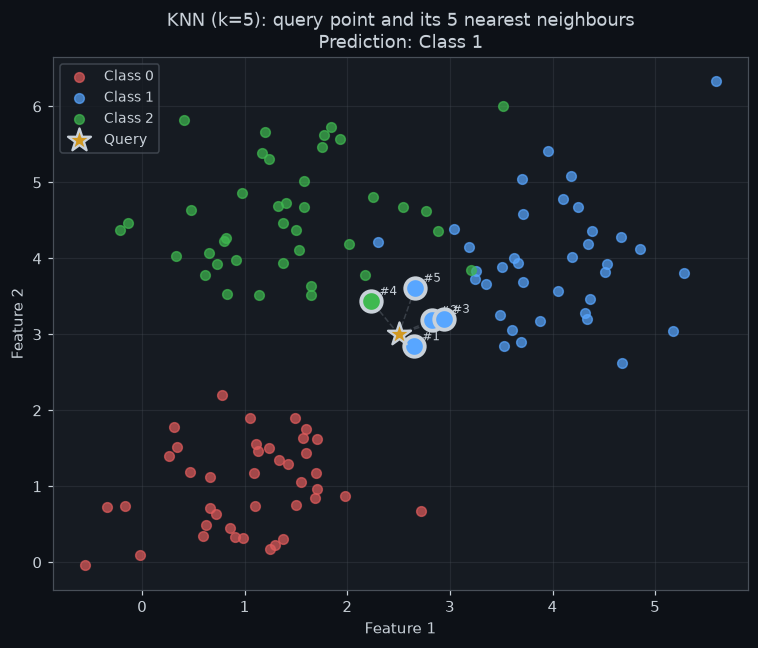

In [4]:
# ── Visualise the single prediction ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

for cls, col in enumerate(class_colors):
    mask = y_train == cls
    ax.scatter(X_train[mask, 0], X_train[mask, 1],
               color=col, s=40, alpha=0.7, label=class_names[cls], zorder=3)

# Highlight the 5 nearest neighbours
for rank, idx in enumerate(k_idx, 1):
    ax.scatter(X_train[idx, 0], X_train[idx, 1],
               s=180, color=class_colors[y_train[idx]],
               edgecolors=TEXT, linewidths=2.5, zorder=4)
    # Draw line to query
    ax.plot([query[0], X_train[idx, 0]], [query[1], X_train[idx, 1]],
            color=MUTED, linewidth=1, linestyle='--', alpha=0.7, zorder=2)
    ax.text(X_train[idx, 0] + 0.08, X_train[idx, 1] + 0.08,
            f'#{rank}', color=TEXT, fontsize=8)

# Query point
ax.scatter(*query, s=250, color=YELLOW, marker='*',
           edgecolors=TEXT, linewidths=1.5, zorder=5, label='Query')

ax.set_title(f'KNN (k=5): query point and its 5 nearest neighbours\nPrediction: Class {prediction}',
             color=TEXT)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()

## Part 3 — Decision boundaries

A decision boundary is the surface in feature space where the prediction changes from one class to another. For KNN there's no analytical formula for this boundary — it's implicitly defined by the training data and $k$.

To visualise it: evaluate the classifier on a dense grid of points and colour each point by its predicted class. The boundary is where the colours change.

The shape of the boundary is highly sensitive to $k$ — this is the most important hyperparameter in KNN.

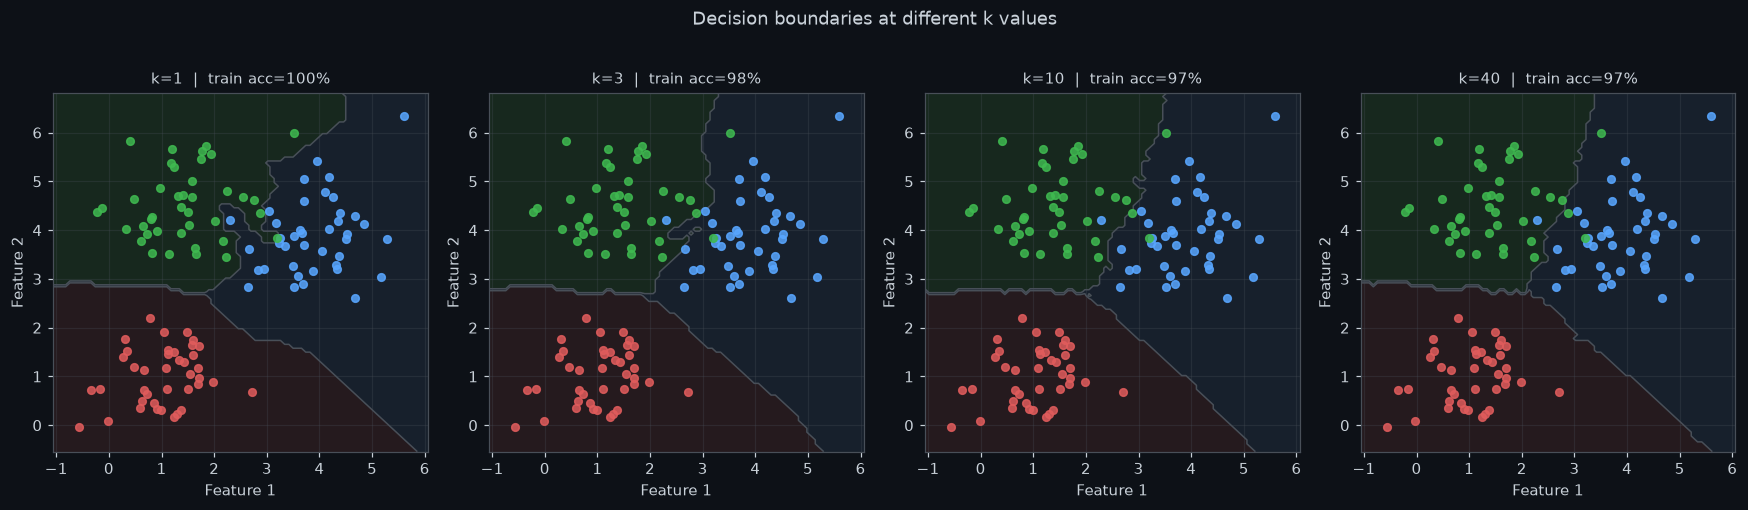

k=1:  every training point is its own region — jagged boundary, 100% training accuracy
k=3:  smoother but still complex — captures local structure
k=10: smooth, generalises well — good balance for this dataset
k=40: over-smoothed — boundary too blunt, misses genuine structure


In [5]:
def plot_decision_boundary(ax, knn, X, y, title, resolution=0.08):
    """Colour the feature space by predicted class."""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, resolution),
        np.arange(y_min, y_max, resolution)
    )
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = knn.predict(grid_points).reshape(xx.shape)

    # Soft background colours
    bg_colors = ['#3d1a1a', '#1a2a3d', '#1a3d1a']
    cmap_bg = ListedColormap(bg_colors)
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg, levels=[-0.5, 0.5, 1.5, 2.5])
    ax.contour( xx, yy, Z, colors=[MUTED], linewidths=1.0, levels=[0.5, 1.5])

    # Training points
    for cls, col in enumerate(class_colors):
        mask = y == cls
        ax.scatter(X[mask, 0], X[mask, 1], color=col, s=25, alpha=0.85, zorder=3)

    ax.set_title(title, color=TEXT, fontsize=10)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.grid(True)


k_values = [1, 3, 10, 40]
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))

for ax, k in zip(axes, k_values):
    knn_k = KNN(k=k).fit(X_train, y_train)
    train_preds = knn_k.predict(X_train)
    train_acc   = (train_preds == y_train).mean()
    plot_decision_boundary(ax, knn_k, X_train, y_train,
                           title=f'k={k}  |  train acc={train_acc:.0%}')

fig.suptitle('Decision boundaries at different k values',
             color=TEXT, fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("k=1:  every training point is its own region — jagged boundary, 100% training accuracy")
print("k=3:  smoother but still complex — captures local structure")
print("k=10: smooth, generalises well — good balance for this dataset")
print("k=40: over-smoothed — boundary too blunt, misses genuine structure")

## Part 4 — The bias-variance tradeoff in KNN

The $k=1$ boundary above memorises every training point perfectly — 100% training accuracy. But it's fitting noise, not signal. The $k=40$ boundary ignores local structure that's genuinely real.

This is the **bias-variance tradeoff** made concrete:

**Small $k$** → low bias (flexible, fits training data closely), high variance (sensitive to individual noisy points, changes a lot if training data changes)

**Large $k$** → high bias (smooth, may miss real patterns), low variance (stable, changes little with new training data)

In KNN the tradeoff is unusually transparent because $k$ is the only parameter and its effect on the boundary is directly visible.

The right $k$ minimises **test error**, not training error. The way to find it: **cross-validation**.

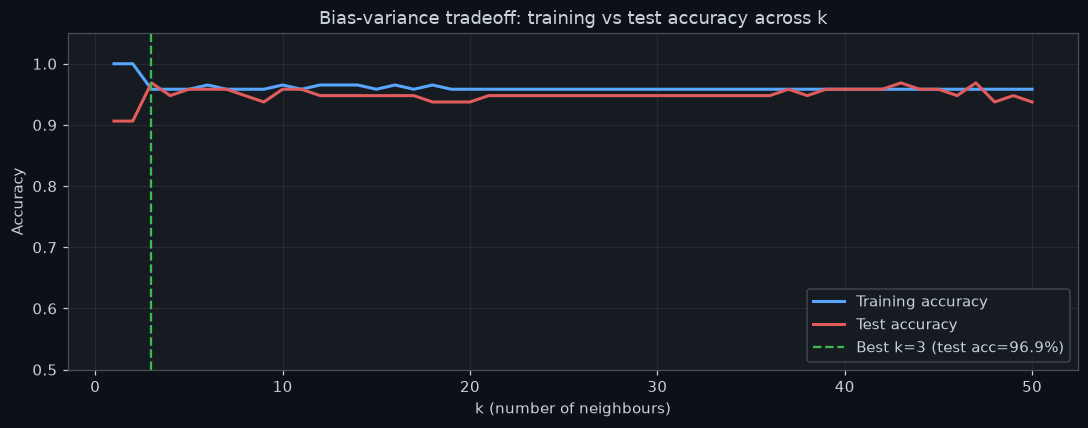

k=1:       training acc=100.0%, test acc=90.6%  ← overfit
k=3:      training acc=95.8%, test acc=96.9%  ← best generalisation
k=50:      training acc=95.8%, test acc=93.8%  ← underfit


In [6]:
# ── Cross-validation to find optimal k ────────────────────────────────────────
# Generate a train/test split and sweep k

X_all, y_all = make_blobs(n_per_class=80, seed=0)
n = len(X_all)

# 60/40 train/test split
shuffle_idx = np.random.permutation(n)
split = int(0.6 * n)
X_tr, y_tr = X_all[shuffle_idx[:split]], y_all[shuffle_idx[:split]]
X_te, y_te = X_all[shuffle_idx[split:]], y_all[shuffle_idx[split:]]

k_range     = range(1, 51)
train_accs  = []
test_accs   = []

for k in k_range:
    knn_k = KNN(k=k).fit(X_tr, y_tr)
    train_accs.append((knn_k.predict(X_tr) == y_tr).mean())
    test_accs.append( (knn_k.predict(X_te) == y_te).mean())

best_k   = k_range.start + np.argmax(test_accs)
best_acc = max(test_accs)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_range, train_accs, color=BLUE,   linewidth=2,   label='Training accuracy')
ax.plot(k_range, test_accs,  color=ACCENT, linewidth=2,   label='Test accuracy')
ax.axvline(best_k, color=GREEN, linestyle='--', linewidth=1.5,
           label=f'Best k={best_k} (test acc={best_acc:.1%})')
ax.set_title('Bias-variance tradeoff: training vs test accuracy across k', color=TEXT)
ax.set_xlabel('k (number of neighbours)')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True)
ax.set_ylim(0.5, 1.05)
plt.tight_layout()
plt.show()

print(f"k=1:       training acc={train_accs[0]:.1%}, test acc={test_accs[0]:.1%}  ← overfit")
print(f"k={best_k}:      training acc={train_accs[best_k-1]:.1%}, test acc={test_accs[best_k-1]:.1%}  ← best generalisation")
print(f"k=50:      training acc={train_accs[49]:.1%}, test acc={test_accs[49]:.1%}  ← underfit")

## Part 5 — Feature scaling: the hidden requirement

KNN depends entirely on distances. If features are on different scales, the feature with the largest range dominates the distance calculation, and other features are effectively ignored.

Example: predicting house prices from square footage (range: 500–5000) and number of bedrooms (range: 1–6). Euclidean distance will be almost entirely determined by square footage — the bedroom count contributes almost nothing.

**Standard scaling** (z-score normalisation) fixes this:

$$x_j^{\text{scaled}} = \frac{x_j - \mu_j}{\sigma_j}$$

Each feature becomes mean-zero, unit-variance. All features contribute equally to distance.

Unscaled  : test accuracy = 100.0%
Scaled    : test accuracy = 100.0%

Feature 1 range (unscaled): 60 – 255
Feature 2 range (unscaled): 1.01 – 5.35

Feature 1 range (scaled):   -1.61 – 1.90
Feature 2 range (scaled):   -1.64 – 2.01


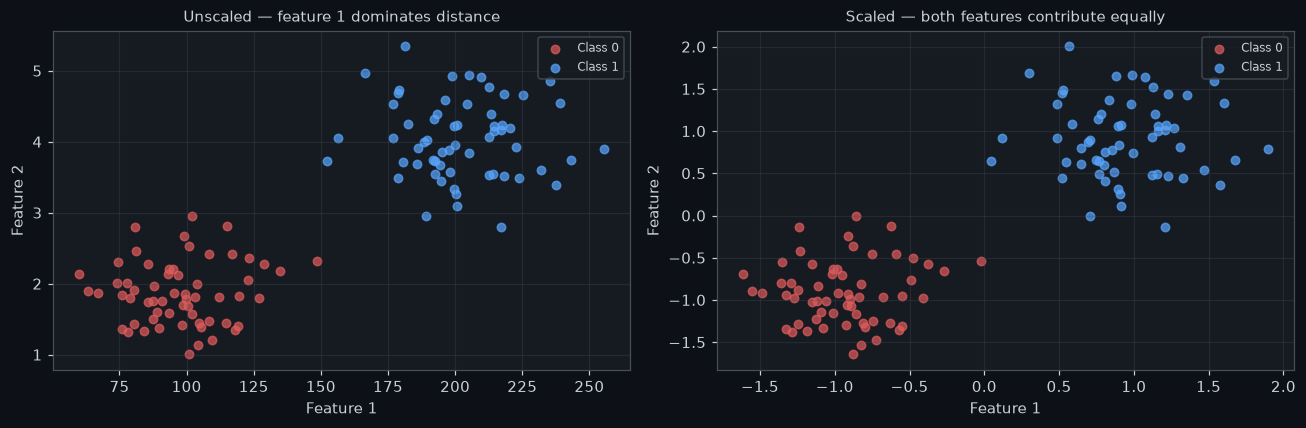

In [7]:
# ── Demonstrate the scaling problem ───────────────────────────────────────────
rng = np.random.default_rng(5)

# Two classes, genuinely separable in both dimensions
X_raw = np.vstack([
    rng.normal([100, 2.0], [20, 0.5], (60, 2)),   # class 0
    rng.normal([200, 4.0], [20, 0.5], (60, 2)),   # class 1
])
y_raw = np.array([0]*60 + [1]*60)

# Scaled version
mu    = X_raw.mean(axis=0)
sigma = X_raw.std(axis=0)
X_scaled = (X_raw - mu) / sigma

# Train/test split
idx = np.random.permutation(120)
tr, te = idx[:80], idx[80:]

for label, X in [('Unscaled', X_raw), ('Scaled', X_scaled)]:
    knn_test = KNN(k=5).fit(X[tr], y_raw[tr])
    acc = (knn_test.predict(X[te]) == y_raw[te]).mean()
    print(f"{label:10s}: test accuracy = {acc:.1%}")

print()
print(f"Feature 1 range (unscaled): {X_raw[:,0].min():.0f} – {X_raw[:,0].max():.0f}")
print(f"Feature 2 range (unscaled): {X_raw[:,1].min():.2f} – {X_raw[:,1].max():.2f}")
print(f"\nFeature 1 range (scaled):   {X_scaled[:,0].min():.2f} – {X_scaled[:,0].max():.2f}")
print(f"Feature 2 range (scaled):   {X_scaled[:,1].min():.2f} – {X_scaled[:,1].max():.2f}")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, X_plot, title in zip(axes,
                              [X_raw, X_scaled],
                              ['Unscaled — feature 1 dominates distance',
                               'Scaled — both features contribute equally']):
    for cls, col in enumerate([ACCENT, BLUE]):
        mask = y_raw == cls
        ax.scatter(X_plot[mask, 0], X_plot[mask, 1],
                   color=col, s=30, alpha=0.7, label=f'Class {cls}')
    ax.set_title(title, color=TEXT, fontsize=10)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
plt.show()

## Part 6 — KNN for regression

Everything above was classification. KNN regression works identically except the final step: instead of a majority vote, take the **mean** of the $k$ nearest neighbours' target values.

$$\hat{y}(\mathbf{x}_q) = \frac{1}{k} \sum_{i \in \mathcal{N}_k(\mathbf{x}_q)} y_i$$

A weighted variant gives closer neighbours more influence:

$$\hat{y}(\mathbf{x}_q) = \frac{\sum_{i \in \mathcal{N}_k} w_i y_i}{\sum_{i \in \mathcal{N}_k} w_i}, \quad w_i = \frac{1}{d(\mathbf{x}_q, \mathbf{x}_i)}$$

The predicted function is piecewise constant (unweighted) or piecewise smooth (distance-weighted) — it can't extrapolate beyond the training data range.

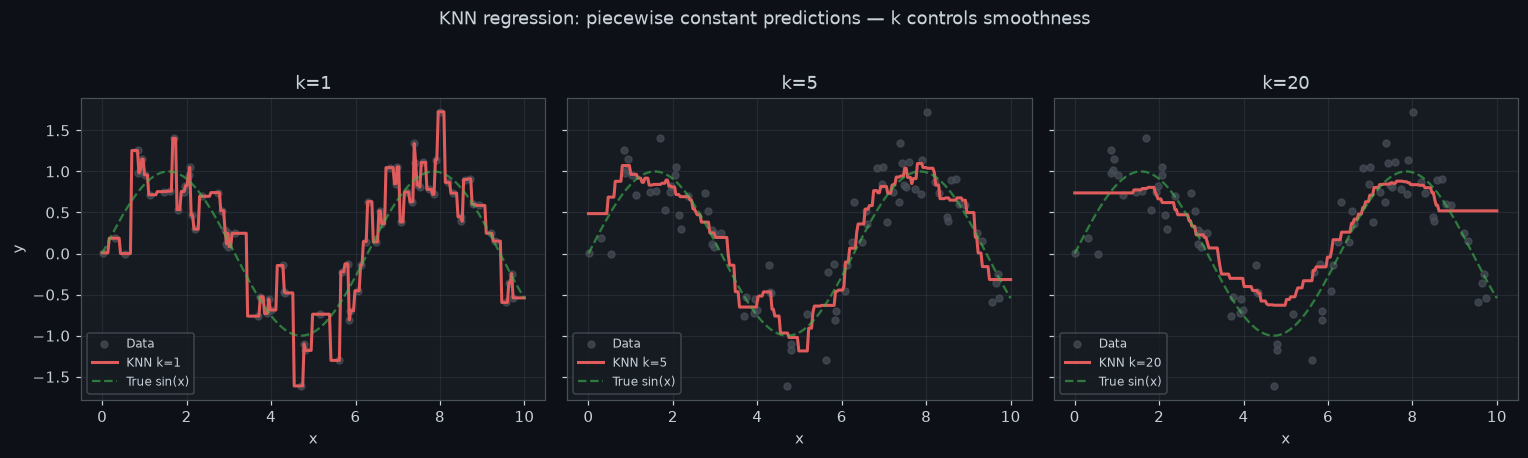

k=1:  interpolates exactly through every training point — overfits noise
k=5:  smooth enough to track the sine wave, flexible enough to follow it
k=20: over-smoothed — flattens peaks and troughs


In [8]:
# ── KNN regression ────────────────────────────────────────────────────────────
rng = np.random.default_rng(3)
x_reg = np.sort(rng.uniform(0, 10, 80))
y_reg = np.sin(x_reg) + 0.3 * rng.normal(0, 1, 80)

X_reg = x_reg.reshape(-1, 1)
x_plot = np.linspace(0, 10, 300).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, k in zip(axes, [1, 5, 20]):
    knn_reg = KNN(k=k, task='regression').fit(X_reg, y_reg)
    y_pred  = knn_reg.predict(x_plot)

    ax.scatter(x_reg, y_reg, color=MUTED, s=20, alpha=0.7, label='Data', zorder=2)
    ax.plot(x_plot, y_pred,  color=ACCENT, linewidth=2, label=f'KNN k={k}', zorder=3)
    ax.plot(x_plot, np.sin(x_plot), color=GREEN, linewidth=1.5,
            linestyle='--', alpha=0.6, label='True sin(x)', zorder=3)
    ax.set_title(f'k={k}', color=TEXT)
    ax.set_xlabel('x')
    if ax == axes[0]:
        ax.set_ylabel('y')
    ax.legend(fontsize=8)
    ax.grid(True)

fig.suptitle('KNN regression: piecewise constant predictions — k controls smoothness',
             color=TEXT, y=1.03)
plt.tight_layout()
plt.show()

print("k=1:  interpolates exactly through every training point — overfits noise")
print("k=5:  smooth enough to track the sine wave, flexible enough to follow it")
print("k=20: over-smoothed — flattens peaks and troughs")

## Part 7 — The curse of dimensionality

KNN's fatal weakness at scale. In high-dimensional spaces, the concept of "nearest neighbours" breaks down.

### The empty space problem

Consider a unit hypercube in $d$ dimensions. To capture a fraction $r$ of the data volume, a hypercube of side length $r^{1/d}$ is needed. In 1D, capturing 1% of the range requires a window of width 0.01. In 10D, a hypercube of side $0.01^{1/10} \approx 0.63$ is needed — more than half the range in every dimension simultaneously. The neighbourhood has to be enormous to contain enough points.

### The distance concentration problem

In high dimensions, the ratio of the distance to the *furthest* neighbour to the distance to the *nearest* neighbour converges to 1. All points become approximately equidistant. The concept of a "nearest" neighbour loses meaning when the nearest and furthest are essentially the same distance away.

$$\lim_{d \to \infty} \frac{\max_i d(\mathbf{x}_q, \mathbf{x}_i) - \min_i d(\mathbf{x}_q, \mathbf{x}_i)}{\min_i d(\mathbf{x}_q, \mathbf{x}_i)} \to 0$$

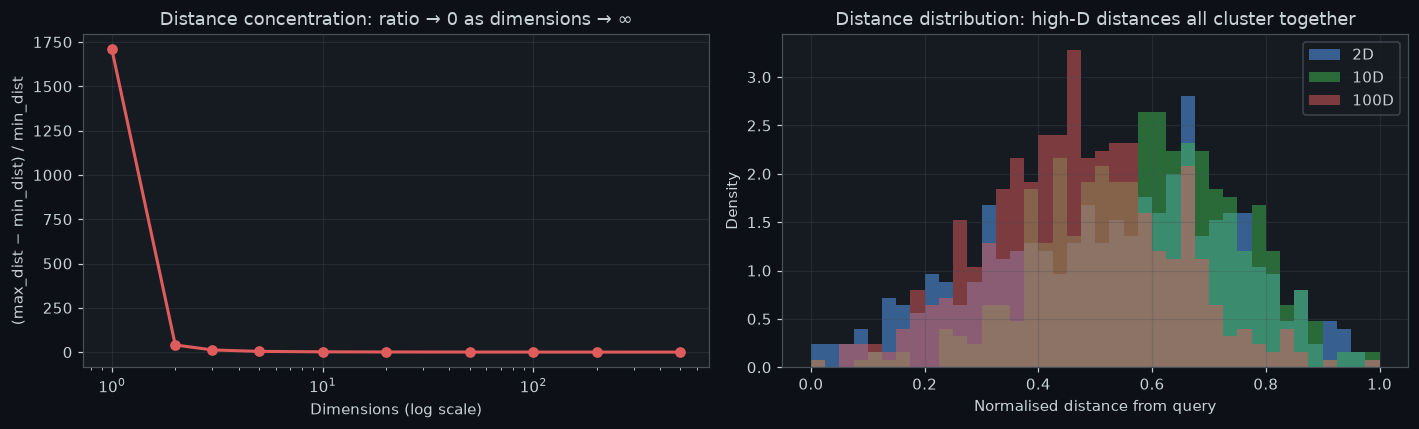

In 2D: clear spread of distances — nearest and furthest are distinct.
In 100D: all distances compress into a narrow band — 'nearest' loses meaning.

Practical consequence: KNN degrades badly above ~20 features.
Dimensionality reduction (PCA etc.) before KNN is often essential.


In [9]:
# ── Demonstrate distance concentration ────────────────────────────────────────
# In each dimension, sample 500 points and measure the ratio
# (max distance - min distance) / min distance from a fixed query point

dims = [1, 2, 3, 5, 10, 20, 50, 100, 200, 500]
n_pts = 500
n_trials = 30
ratios = []

for d in dims:
    trial_ratios = []
    for _ in range(n_trials):
        X_d     = np.random.uniform(0, 1, (n_pts, d))
        query_d = np.zeros(d)   # origin as query
        dists_d = np.sqrt(((X_d - query_d)**2).sum(axis=1))
        ratio   = (dists_d.max() - dists_d.min()) / (dists_d.min() + 1e-10)
        trial_ratios.append(ratio)
    ratios.append(np.mean(trial_ratios))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.semilogx(dims, ratios, color=ACCENT, marker='o', linewidth=2)
ax.set_title('Distance concentration: ratio → 0 as dimensions → ∞', color=TEXT)
ax.set_xlabel('Dimensions (log scale)')
ax.set_ylabel('(max_dist − min_dist) / min_dist')
ax.grid(True)

# Show how neighbour distances cluster in high vs low dimensions
ax = axes[1]
for d, col, label in [(2, BLUE, '2D'), (10, GREEN, '10D'), (100, ACCENT, '100D')]:
    X_d     = np.random.uniform(0, 1, (500, d))
    query_d = np.zeros(d)
    dists_d = np.sqrt(((X_d - query_d)**2).sum(axis=1))
    # Normalise to [0,1] for comparison
    dists_norm = (dists_d - dists_d.min()) / (dists_d.max() - dists_d.min() + 1e-10)
    ax.hist(dists_norm, bins=40, density=True, color=col, alpha=0.5, label=label)

ax.set_title('Distance distribution: high-D distances all cluster together', color=TEXT)
ax.set_xlabel('Normalised distance from query')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

print("In 2D: clear spread of distances — nearest and furthest are distinct.")
print("In 100D: all distances compress into a narrow band — 'nearest' loses meaning.")
print("\nPractical consequence: KNN degrades badly above ~20 features.")
print("Dimensionality reduction (PCA etc.) before KNN is often essential.")

## Part 8 — Computational cost and approximate methods

KNN's other weakness: prediction cost.

For each query point, naive KNN computes distances to all $n$ training points — $O(nd)$ per query. With $n = 10^6$ training points and $d = 100$ features, each prediction requires $10^8$ floating point operations. This is fine for small datasets; it's prohibitive at scale.

### Exact speedups: tree structures

**KD-Trees** recursively partition the feature space using axis-aligned splits. For a query, you can prune entire branches of the tree without checking every point — average case $O(d \log n)$ rather than $O(nd)$. Works well in low dimensions; deteriorates above ~20D (the curse again).

**Ball Trees** partition using hyperspheres rather than boxes. Better in high dimensions than KD-trees, but still suffers above ~30D.

### Approximate nearest neighbours (ANN)

For large-scale applications — vector databases, semantic search, recommendation systems — exact nearest neighbours aren't necessary. Algorithms like **HNSW** (Hierarchical Navigable Small World graphs) and **FAISS** (Facebook AI Similarity Search) return approximate neighbours in $O(\log n)$ time with controllable accuracy tradeoffs.

Every time you do a semantic search in a RAG pipeline or get a recommendation on a streaming platform, there's almost certainly an ANN index underneath it.

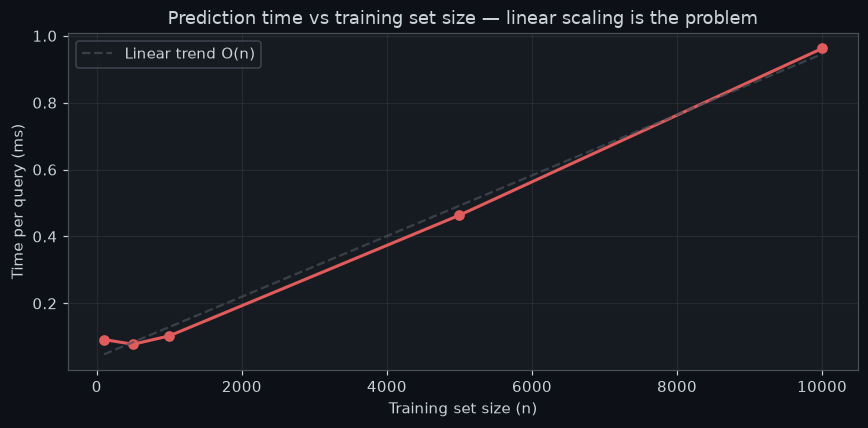

Prediction time scales linearly with n — every training point checked for every query.
At n=1M this becomes impractical for real-time applications.
Solution: approximate nearest neighbour indices (HNSW, FAISS, ScaNN).


In [10]:
# ── Prediction time scaling ────────────────────────────────────────────────────
import time

n_sizes = [100, 500, 1000, 5000, 10000]
times   = []
n_queries = 20

for n_train in n_sizes:
    X_t = np.random.randn(n_train, 10)
    y_t = np.random.randint(0, 3, n_train)
    X_q = np.random.randn(n_queries, 10)

    knn_t = KNN(k=5).fit(X_t, y_t)

    start = time.perf_counter()
    knn_t.predict(X_q)
    elapsed = time.perf_counter() - start

    times.append(elapsed / n_queries * 1000)   # ms per query

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_sizes, times, color=ACCENT, marker='o', linewidth=2)

# Fit a linear trend to confirm O(n) scaling
coeffs = np.polyfit(n_sizes, times, 1)
trend  = np.poly1d(coeffs)
ax.plot(n_sizes, trend(n_sizes), color=MUTED, linestyle='--',
        alpha=0.7, label='Linear trend O(n)')

ax.set_title('Prediction time vs training set size — linear scaling is the problem', color=TEXT)
ax.set_xlabel('Training set size (n)')
ax.set_ylabel('Time per query (ms)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

print("Prediction time scales linearly with n — every training point checked for every query.")
print("At n=1M this becomes impractical for real-time applications.")
print("Solution: approximate nearest neighbour indices (HNSW, FAISS, ScaNN).")

## Summary

| Concept | What it is |
|---------|------------|
| **Lazy learning** | No training phase — the data is the model; all work at prediction time |
| **Distance metric** | The definition of 'close'; Euclidean is default but the choice matters |
| **k** | Number of neighbours; the only hyperparameter; controls bias-variance tradeoff |
| **Small k** | Low bias, high variance — flexible, overfits noise |
| **Large k** | High bias, low variance — smooth, may miss real structure |
| **Feature scaling** | Required — unscaled features dominate distances |
| **Curse of dimensionality** | Distances concentrate in high dimensions; nearest neighbour loses meaning |
| **Prediction cost** | O(nd) per query — prohibitive at scale without ANN indexing |

---

### The key equations

**Euclidean distance:**
$$\boxed{d(\mathbf{x}, \mathbf{x}') = \sqrt{\sum_{j=1}^{d}(x_j - x_j')^2}}$$

**KNN classification:**
$$\boxed{\hat{y}(\mathbf{x}_q) = \text{mode}\{y_i : i \in \mathcal{N}_k(\mathbf{x}_q)\}}$$

**KNN regression:**
$$\boxed{\hat{y}(\mathbf{x}_q) = \frac{1}{k}\sum_{i \in \mathcal{N}_k(\mathbf{x}_q)} y_i}$$

---

## Things to try

- Change the distance metric from `euclidean` to `manhattan` — do the decision boundaries change?
- Implement distance-weighted voting: closer neighbours count more. Does it improve accuracy on the test set?
- Try KNN on a dataset where classes form concentric rings rather than blobs — what value of k works best?
- Add a deliberately irrelevant feature (pure noise) to the blob data and observe how test accuracy degrades as k varies
- Implement a simple KD-tree for 2D data and compare its prediction time against the naive implementation